In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.splits.io import load_splits

paths = load_paths()
logger = setup_logger(level="INFO")

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
print("="*60)
print("1. RAW DATA ANALYSIS")
print("="*60)

# Load Raw Flows
logger.info("Loading raw flows...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")

vnat_flows["dataset"] = "vnat"
iscx_flows["dataset"] = "iscx"

print(f"VNAT Flows: {len(vnat_flows)}")
print(f"ISCX Flows: {len(iscx_flows)}")

# Combine for easier analysis
all_flows = pd.concat([vnat_flows, iscx_flows], ignore_index=True)


1. RAW DATA ANALYSIS
2026-03-22 02:31:27 | INFO | ai-vpn-firewall | Loading raw flows...
VNAT Flows: 33711
ISCX Flows: 76687



--- Class Balance (Raw) ---
label        0      1  total  vpn_ratio
dataset                                
iscx     54254  22433  76687   0.292527
vnat     33332    379  33711   0.011243


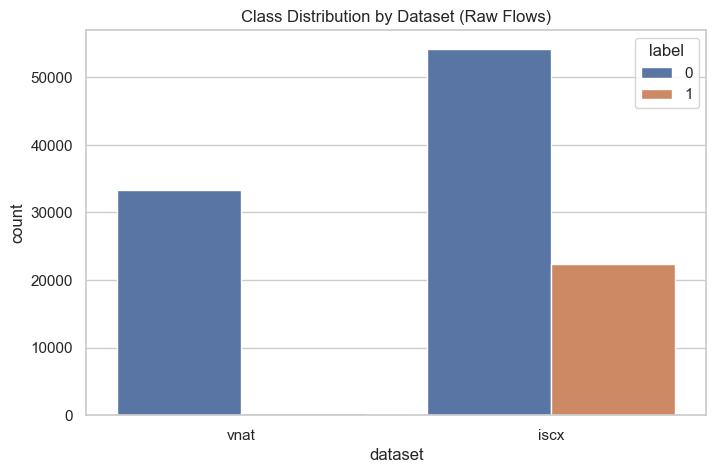

In [3]:
# 1.1 Class Balance
print("\n--- Class Balance (Raw) ---")
balance = all_flows.groupby(["dataset", "label"]).size().unstack(fill_value=0)
balance["total"] = balance.sum(axis=1)
balance["vpn_ratio"] = balance[1] / balance["total"]
print(balance)

plt.figure(figsize=(8, 5))
sns.countplot(data=all_flows, x="dataset", hue="label")
plt.title("Class Distribution by Dataset (Raw Flows)")
plt.show()


In [4]:
# 1.2 Capture Analysis
print("\n--- Capture Analysis ---")
# Check for mixed labels in captures
mixed_caps = all_flows.groupby("capture_id")["label"].nunique()
mixed_caps = mixed_caps[mixed_caps > 1]

if len(mixed_caps) > 0:
    print(f"WARNING: Found {len(mixed_caps)} captures with mixed labels (both VPN and Non-VPN flows):")
    print(mixed_caps.head(10))
else:
    print("CONFIRMED: All captures are pure (contain only VPN or only Non-VPN flows).")

# Top captures by flow count
top_caps = all_flows["capture_id"].value_counts().head(10)
print("\nTop 10 Largest Captures:")
print(top_caps)



--- Capture Analysis ---
CONFIRMED: All captures are pure (contain only VPN or only Non-VPN flows).

Top 10 Largest Captures:
capture_id
nonvpn_ssh_capture5.pcap         11368
nonvpn_scp_long_capture1.pcap    10555
nonvpn_hangouts_audio4.pcapng    10504
nonvpn_facebook_audio4.pcapng     7425
vpn_vpn_hangouts_audio2.pcap      5478
nonvpn_scp1.pcapng                4911
nonvpn_skype_file8.pcapng         4781
vpn_vpn_hangouts_audio1.pcap      3622
nonvpn_skype_audio3.pcapng        3175
vpn_vpn_facebook_audio2.pcap      1737
Name: count, dtype: int64


In [5]:
print("\n" + "="*60)
print("2. SPLIT ANALYSIS (THE 'AFTER' STATE)")
print("="*60)

# Load Canonical Splits
logger.info("Loading canonical splits...")
vnat_splits = load_splits(
    paths.data_splits / "vnat_train_captures.txt",
    paths.data_splits / "vnat_val_captures.txt",
    paths.data_splits / "vnat_test_captures.txt"
)
iscx_splits = load_splits(
    paths.data_splits / "iscx_train_captures.txt",
    paths.data_splits / "iscx_val_captures.txt",
    paths.data_splits / "iscx_test_captures.txt"
)

# Create mapping
cap_to_split = {}
for split_name, caps in vnat_splits.items():
    for c in caps: cap_to_split[str(c)] = split_name
for split_name, caps in iscx_splits.items():
    for c in caps: cap_to_split[str(c)] = split_name

logger.info("Mapping flows to splits...")
all_flows["split"] = all_flows["capture_id"].astype(str).map(cap_to_split).fillna("unknown")

unknown_n = int((all_flows["split"] == "unknown").sum())
if unknown_n > 0:
    raise ValueError(f"Found {unknown_n} flows with unknown split assignment.")

print("\nSplit Distribution (Flow Counts):")
print(all_flows["split"].value_counts())



2. SPLIT ANALYSIS (THE 'AFTER' STATE)
2026-03-22 02:31:29 | INFO | ai-vpn-firewall | Loading canonical splits...
2026-03-22 02:31:29 | INFO | ai-vpn-firewall | Mapping flows to splits...

Split Distribution (Flow Counts):
split
train    79064
test     17041
val      14293
Name: count, dtype: int64


In [6]:
# 2.1 Leakage Check (Capture Overlap)
print("\n--- Leakage Check ---")
train_caps = set(all_flows[all_flows["split"]=="train"]["capture_id"])
val_caps = set(all_flows[all_flows["split"]=="val"]["capture_id"])
test_caps = set(all_flows[all_flows["split"]=="test"]["capture_id"])

overlap_tv = train_caps.intersection(val_caps)
overlap_tt = train_caps.intersection(test_caps)
overlap_vt = val_caps.intersection(test_caps)

if overlap_tv or overlap_tt or overlap_vt:
    print("CRITICAL WARNING: Capture leakage detected!")
    print(f"Train/Val Overlap: {len(overlap_tv)}")
    print(f"Train/Test Overlap: {len(overlap_tt)}")
    print(f"Val/Test Overlap: {len(overlap_vt)}")
else:
    print("CONFIRMED: No capture leakage between splits.")



--- Leakage Check ---
CONFIRMED: No capture leakage between splits.


In [7]:
# 2.2 Voipbuster Check
print("\n--- Voipbuster Holdout Check ---")
vb_caps = [c for c in all_flows["capture_id"].unique() if "voipbuster" in str(c)]
print(f"Found Voipbuster captures: {vb_caps}")

for cap in vb_caps:
    s = all_flows[all_flows["capture_id"] == cap]["split"].iloc[0]
    print(f"  {cap} -> {s}")



--- Voipbuster Holdout Check ---
Found Voipbuster captures: ['nonvpn_voipbuster1b.pcapng', 'nonvpn_voipbuster2b.pcapng', 'nonvpn_voipbuster3b.pcapng', 'nonvpn_voipbuster_4a.pcap', 'nonvpn_voipbuster_4b.pcap', 'vpn_vpn_voipbuster1a.pcap', 'vpn_vpn_voipbuster1b.pcap']
  nonvpn_voipbuster1b.pcapng -> train
  nonvpn_voipbuster2b.pcapng -> train
  nonvpn_voipbuster3b.pcapng -> test
  nonvpn_voipbuster_4a.pcap -> train
  nonvpn_voipbuster_4b.pcap -> train
  vpn_vpn_voipbuster1a.pcap -> test
  vpn_vpn_voipbuster1b.pcap -> val


In [8]:
print("\n" + "="*60)
print("3. FEATURE DISTRIBUTION ANALYSIS")
print("="*60)

# Load processed features if available to save time, else extract sample
# We prefer loading the actual features used in training
vnat_feat_path = paths.data_processed / "vnat" / "features.parquet"
iscx_feat_path = paths.data_processed / "iscx" / "features.parquet"

if vnat_feat_path.exists() and iscx_feat_path.exists():
    logger.info("Loading pre-computed features...")
    vnat_df = pd.read_parquet(vnat_feat_path)
    vnat_df["dataset"] = "vnat"
    iscx_df = pd.read_parquet(iscx_feat_path)
    iscx_df["dataset"] = "iscx"
    df_features = pd.concat([vnat_df, iscx_df], ignore_index=True)

    # FIX: Merge capture_id from all_flows before applying get_split
    if "capture_id" not in df_features.columns:
        logger.info("Merging capture_id from flows into features...")
        # We assume flow_id is the key.
        # all_flows has flow_id, capture_id, dataset
        meta_map = all_flows[["flow_id", "dataset", "capture_id", "label"]]
        # Merge on flow_id and dataset to be safe
        df_features = pd.merge(df_features, meta_map, on=["flow_id", "dataset"], how="left")

    # Re-apply split mapping to features
    df_features["split"] = df_features["capture_id"].astype(str).map(cap_to_split).fillna("unknown")

    # Normalize split names if needed (e.g. if using old features)
    df_features["split"] = df_features["split"].replace({
        "iscx_train": "train",
        "iscx_val": "val",
        "iscx_test": "test",
    })
else:
    logger.warning("Feature files not found. Using flows instead...")
    df_features = all_flows.copy()

print(f"Feature DataFrame: {df_features.shape}")



3. FEATURE DISTRIBUTION ANALYSIS
2026-03-22 02:31:29 | INFO | ai-vpn-firewall | Loading pre-computed features...
Feature DataFrame: (110398, 45)



Comparing features: ['sz_all_mean', 'sz_all_std', 'sz_mean_max', 'sz_mean_min']


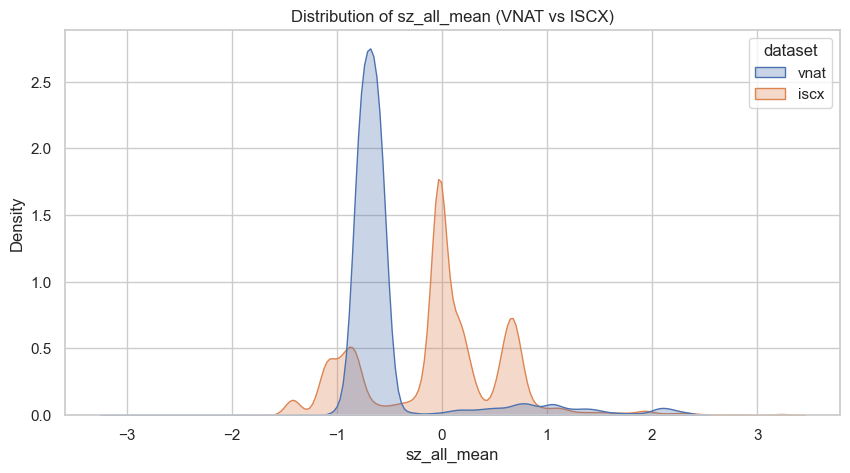

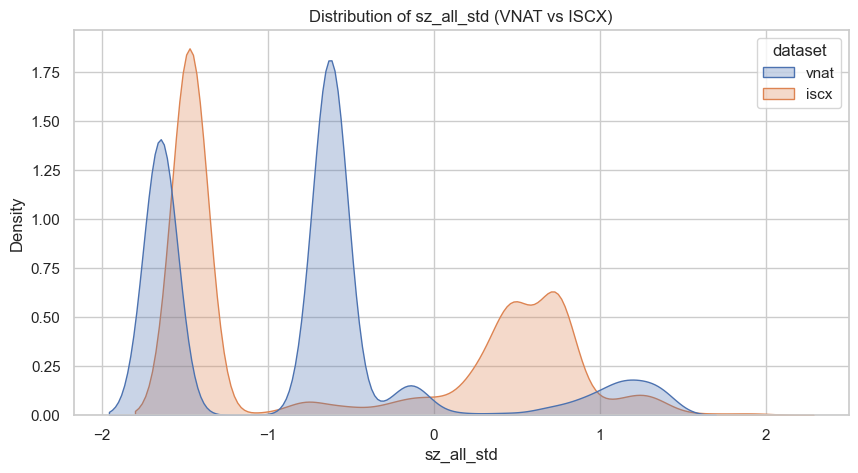

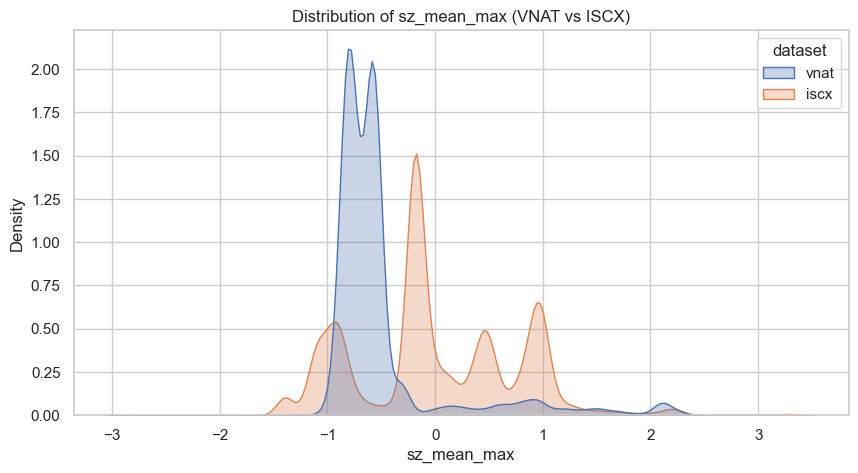

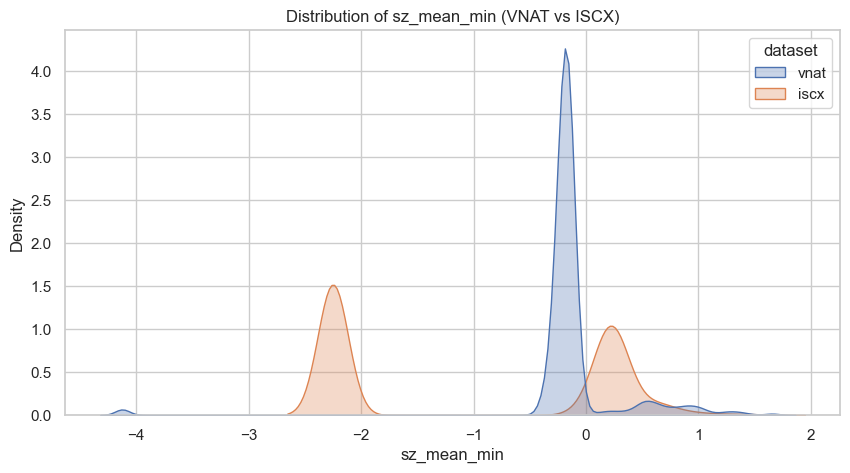

In [9]:
# 3.1 VNAT vs ISCX Feature Shift
# Compare a few key features
key_features = [c for c in df_features.columns if "mean" in c or "std" in c][:4] # Pick first 4 stats

print(f"\nComparing features: {key_features}")

for feat in key_features:
    if feat in df_features.columns:
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df_features, x=feat, hue="dataset", common_norm=False, fill=True, alpha=0.3)
        plt.title(f"Distribution of {feat} (VNAT vs ISCX)")
        plt.show()



--- Train vs Test Feature Shift ---


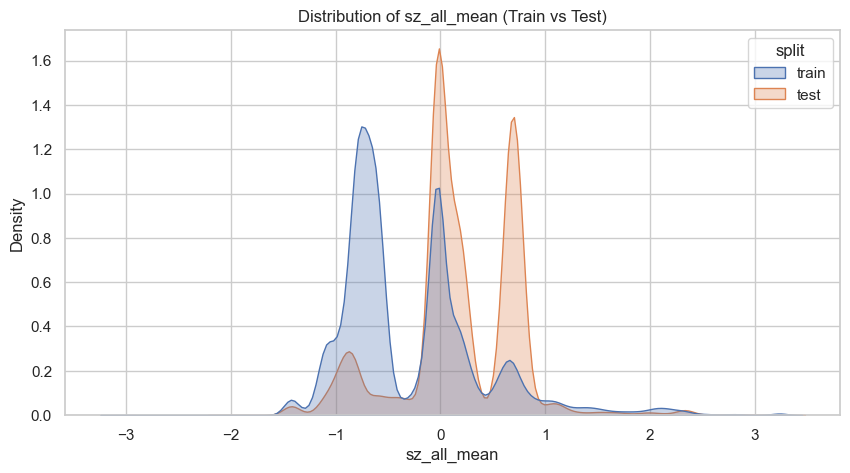

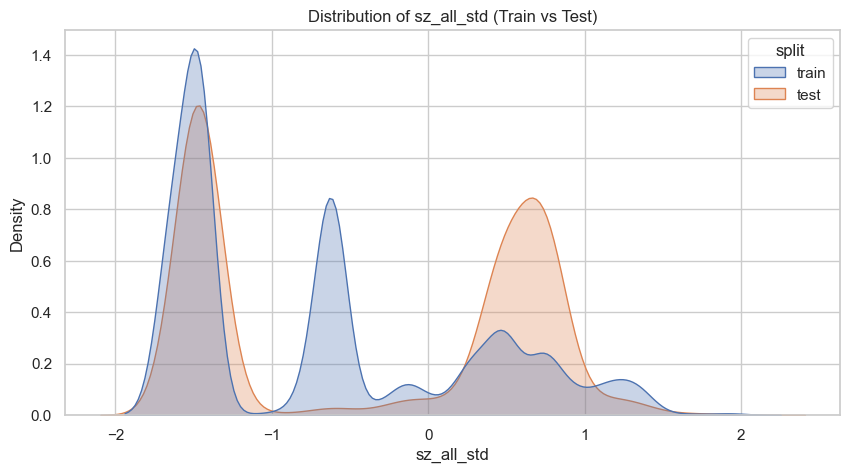

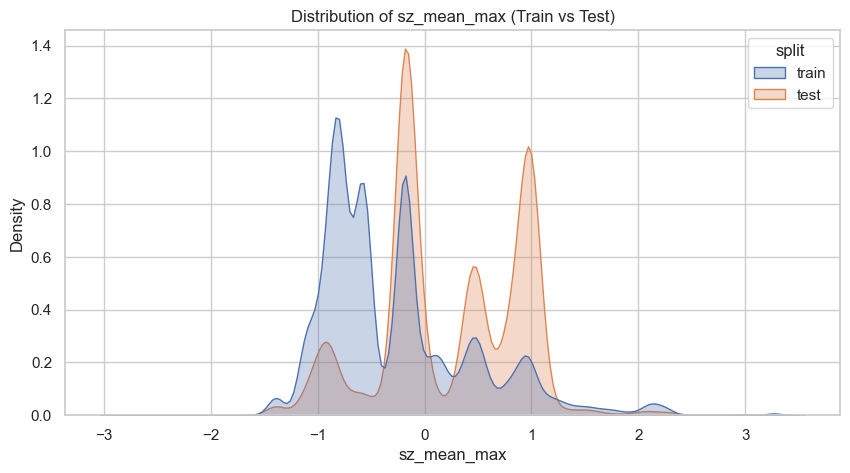

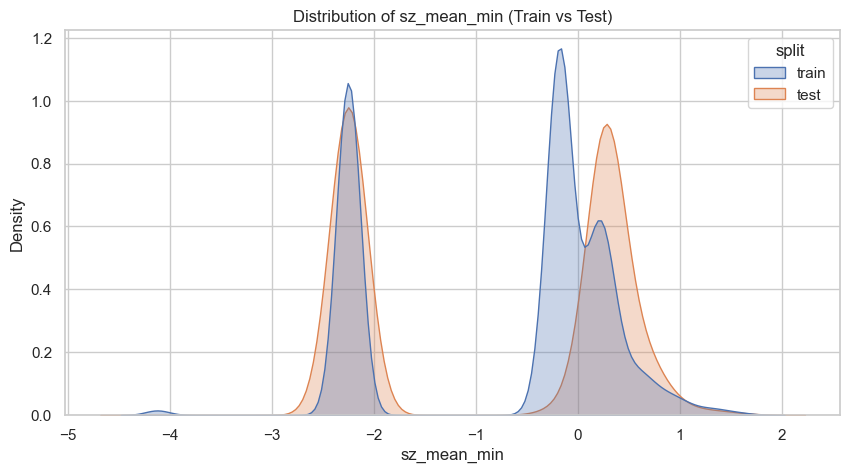

In [10]:
# 3.2 Train vs Test Feature Shift
# This checks if the splits are representative
print("\n--- Train vs Test Feature Shift ---")
for feat in key_features:
    if feat in df_features.columns:
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df_features[df_features["split"].isin(["train", "test"])], x=feat, hue="split", common_norm=False, fill=True, alpha=0.3)
        plt.title(f"Distribution of {feat} (Train vs Test)")
        plt.show()


In [11]:
# 3.3 Correlation Analysis
print("\n--- Correlation Analysis (Top 10 with Label) ---")
numeric_cols = df_features.select_dtypes(include=np.number).columns
# To avoid the error "RuntimeWarning: invalid value encountered in divide"
# when variance is zero, we filter columns with standard deviation > 0
std_devs = df_features[numeric_cols].std()
valid_cols = list(std_devs[std_devs > 0].index)

if valid_cols:
    corrs = df_features[valid_cols].corrwith(df_features["label"]).sort_values(key=abs, ascending=False)
    print(corrs.head(10))



--- Correlation Analysis (Top 10 with Label) ---
label            1.000000
h_iat_all_01     0.418027
h_iat_all_08     0.362837
sz_all_std       0.356198
h_iat_all_00    -0.287851
h_size_all_03    0.230064
sz_mean_max      0.195984
sz_mean_min      0.179836
h_size_all_00    0.163989
sz_all_p75       0.154700
dtype: float64


In [12]:
print("\n" + "="*60)
print("4. FORENSIC MULTI-DOMAIN DATA ANALYSIS (VNAT, ISCX, USBVPN)")
print("="*60)

logger.info("Loading USBVPN data for forensic analysis...")
try:
    usbvpn_flows = pd.read_parquet(paths.data_processed / "usbvpn" / "flows.parquet")
    usbvpn_df = usbvpn_flows.copy()
    usbvpn_df["dataset"] = "usbvpn"

    # Combine all three datasets for this specific analysis
    # Since USBVPN is already pre-extracted in flows.parquet!
    forensic_df = pd.concat([df_features[df_features["dataset"].isin(["vnat", "iscx"])], usbvpn_df], ignore_index=True)

except Exception as e:
    logger.error(f"Could not load USBVPN data: {e}")
    forensic_df = df_features.copy()



4. FORENSIC MULTI-DOMAIN DATA ANALYSIS (VNAT, ISCX, USBVPN)
2026-03-22 02:31:38 | INFO | ai-vpn-firewall | Loading USBVPN data for forensic analysis...


In [13]:
# Task 1: Dimensionality & Range Audit
print("\n--- Task 1: Dimensionality & Range Audit ---")
anchor_features = ["sz_mean_max", "sz_mean_min", "iat_all_mean", "tot_pkt"]
available_anchors = [f for f in anchor_features if f in forensic_df.columns]

if available_anchors:
    audit_table = forensic_df.groupby("dataset")[available_anchors].agg(["mean", "std", "min", "max"])
    print("Summary Table (Mean, Std, Min, Max):")
    display(audit_table)

    print("\n--- Extreme Outliers Audit ---")
    for dataset in forensic_df["dataset"].unique():
        print(f"\nOutliers in {dataset.upper()}:")
        ds_data = forensic_df[forensic_df["dataset"] == dataset]
        for f in available_anchors:
            feat_mean = ds_data[f].mean()
            feat_std = ds_data[f].std()
            if feat_std > 0:
                # Defining extreme outlier as > 3 std from mean
                outliers = ds_data[ds_data[f] > feat_mean + 3 * feat_std]
                if len(outliers) > 0:
                    max_val = float(ds_data[f].max())
                    print(f"  {f}: {len(outliers)} flows > 3 std (Max: {max_val:.2f})")
                else:
                    print(f"  {f}: No extreme outliers (> 3 std)")
            else:
                print(f"  {f}: Standard deviation is 0 (constant value)")
else:
    print(f"Anchor features {anchor_features} not found.")



--- Task 1: Dimensionality & Range Audit ---
Summary Table (Mean, Std, Min, Max):


sz_mean_max                                     sz_mean_min  \
               mean         std        min          max        mean   
dataset                                                               
iscx       0.012477    0.760837  -1.683920     3.273591   -1.016092   
usbvpn   894.634178  681.805773  28.000000  5526.224398  138.914042   
vnat      -0.492684    0.596491  -2.807842     2.269164   -0.126962   

                                          iat_all_mean                      \
               std       min          max         mean       std       min   
dataset                                                                      
iscx      1.280974 -2.251088     1.542476    -0.603549  0.291605 -0.700027   
usbvpn   98.650259  0.000000  1278.000000     0.250865  3.464337  0.000000   
vnat      0.524928 -4.124579     1.668135    -0.476182  0.548137 -0.622722   

                         tot_pkt                              
                max         mean          std  min       max  
dataset                                                       
iscx       2.277611          NaN          NaN  NaN       NaN  
usbvpn   300.228459  1423.199264  3972.424569  1.0  100514.0  
vnat       2.348094          NaN          NaN  NaN       NaN


--- Extreme Outliers Audit ---

Outliers in VNAT:
  sz_mean_max: 1193 flows > 3 std (Max: 2.27)
  sz_mean_min: 114 flows > 3 std (Max: 1.67)
  iat_all_mean: 1539 flows > 3 std (Max: 2.35)
  tot_pkt: Standard deviation is 0 (constant value)

Outliers in ISCX:
  sz_mean_max: 283 flows > 3 std (Max: 3.27)
  sz_mean_min: No extreme outliers (> 3 std)
  iat_all_mean: 3640 flows > 3 std (Max: 2.28)
  tot_pkt: Standard deviation is 0 (constant value)

Outliers in USBVPN:
  sz_mean_max: 1160 flows > 3 std (Max: 5526.22)
  sz_mean_min: 676 flows > 3 std (Max: 1278.00)
  iat_all_mean: 141 flows > 3 std (Max: 300.23)
  tot_pkt: 1142 flows > 3 std (Max: 100514.00)



--- Task 2: Visual Domain Overlap Analysis ---


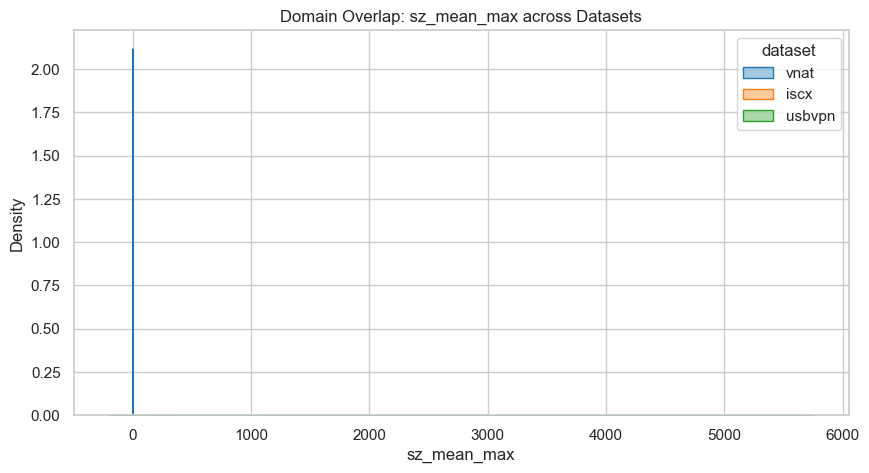

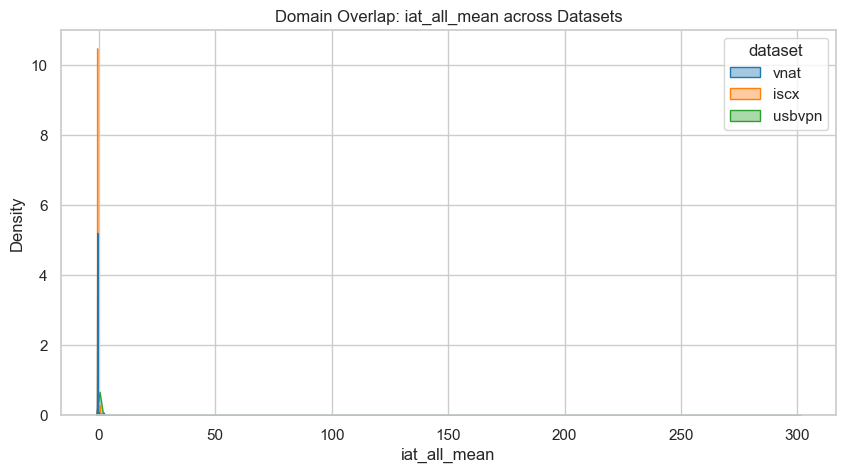

In [14]:
# Task 2: Visual Domain Overlap Analysis
print("\n--- Task 2: Visual Domain Overlap Analysis ---")
overlap_features = ["sz_mean_max", "iat_all_mean"]
available_overlap = [f for f in overlap_features if f in forensic_df.columns]

for feat in available_overlap:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=forensic_df, x=feat, hue="dataset", common_norm=False, fill=True, alpha=0.4, palette="tab10")
    plt.title(f"Domain Overlap: {feat} across Datasets")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.show()


In [15]:
# Task 3: Class-Separability Check (Per Dataset)
print("\n--- Task 3: Class-Separability Check (Per Dataset) ---")
if "label" in forensic_df.columns:
    print("Correlation with Label (VPN=1, Non-VPN=0):")
    for dataset in forensic_df["dataset"].unique():
        ds_data = forensic_df[forensic_df["dataset"] == dataset]
        if len(ds_data["label"].unique()) > 1:
            numeric_cols = ds_data.select_dtypes(include=np.number).columns
            std_devs = ds_data[numeric_cols].std()

            valid_cols_dict = std_devs.to_dict()
            valid_cols = [col for col, std in valid_cols_dict.items() if std > 0]

            if valid_cols:
                corrs = ds_data[valid_cols].corrwith(ds_data["label"])
                print(f"\n{dataset.upper()}:")
                print(corrs[[f for f in available_anchors if f in corrs.index]].to_string())
        else:
            print(f"\n{dataset.upper()}: Cannot compute correlation (only 1 class present).")

    print("\nVanishing Signal Test Analysis:")
    if "sz_mean_max" in forensic_df.columns:
        iscx_data = forensic_df[forensic_df["dataset"] == "iscx"]
        usbvpn_data = forensic_df[forensic_df["dataset"] == "usbvpn"]

        # Use pandas corr to get correlation matrix
        iscx_corr = "N/A"
        if len(iscx_data["label"].unique()) > 1 and iscx_data["sz_mean_max"].std() > 0:
            iscx_corr = iscx_data[["sz_mean_max", "label"]].corr().iloc[0, 1]

        usbvpn_corr = "N/A"
        if not usbvpn_data.empty and len(usbvpn_data["label"].unique()) > 1 and usbvpn_data["sz_mean_max"].std() > 0:
            usbvpn_corr = usbvpn_data[["sz_mean_max", "label"]].corr().iloc[0, 1]

        print(f"ISCX sz_mean_max correlation with label: {iscx_corr}")
        print(f"USBVPN sz_mean_max correlation with label: {usbvpn_corr}")



--- Task 3: Class-Separability Check (Per Dataset) ---
Correlation with Label (VPN=1, Non-VPN=0):

VNAT:
sz_mean_max    -0.013753
sz_mean_min    -0.579358
iat_all_mean    0.065592

ISCX:
sz_mean_max     0.123793
sz_mean_min     0.367439
iat_all_mean   -0.058019

USBVPN:
sz_mean_max     0.242717
sz_mean_min     0.060088
iat_all_mean   -0.016663
tot_pkt         0.623208

Vanishing Signal Test Analysis:
ISCX sz_mean_max correlation with label: 0.12379339092278178
USBVPN sz_mean_max correlation with label: 0.2427168940895445



--- Task 4: Feature Interaction Investigation ---


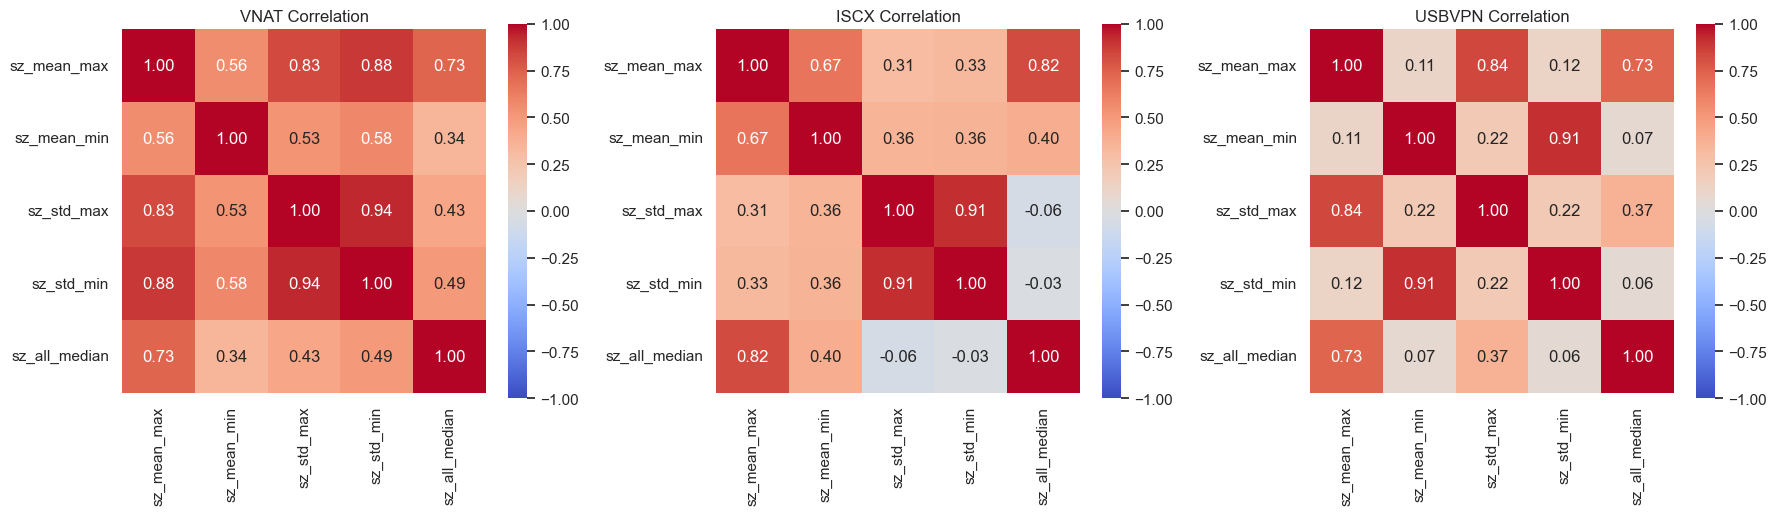

In [16]:
# Task 4: Feature Interaction Investigation
print("\n--- Task 4: Feature Interaction Investigation ---")
blind_5 = ["sz_mean_max", "sz_mean_min", "sz_std_max", "sz_std_min", "sz_all_median"]
available_blind_5 = [f for f in blind_5 if f in forensic_df.columns]

if available_blind_5:
    datasets = forensic_df["dataset"].unique()
    # Create subplots dynamically based on datasets
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
    if len(datasets) == 1:
        axes = [axes] # Make it iterable

    for ax, dataset in zip(axes, datasets):
        ds_data = forensic_df[forensic_df["dataset"] == dataset][available_blind_5]
        # Drop columns with zero variance to avoid NaN correlations
        numeric_cols_interaction = ds_data.select_dtypes(include=np.number).columns
        std_devs_interaction = ds_data[numeric_cols_interaction].std()

        valid_cols_dict = std_devs_interaction.to_dict()
        valid_cols_interaction = [col for col, std in valid_cols_dict.items() if std > 0]

        cols_to_use = [c for c in available_blind_5 if c in valid_cols_interaction]

        if len(cols_to_use) > 0:
            corr_matrix = ds_data[cols_to_use].corr()
            sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, square=True, fmt=".2f")
            ax.set_title(f"{dataset.upper()} Correlation")
        else:
            ax.set_title(f"{dataset.upper()} (No variance)")

    plt.tight_layout()
    plt.show()



--- Task 5: WireGuard vs. The World (Protocol Deep-Dive) ---
2026-03-22 02:31:42 | WARNING | ai-vpn-firewall | No explicit 'wireguard' captures found in USBVPN. Falling back to all VPN flows in USBVPN.


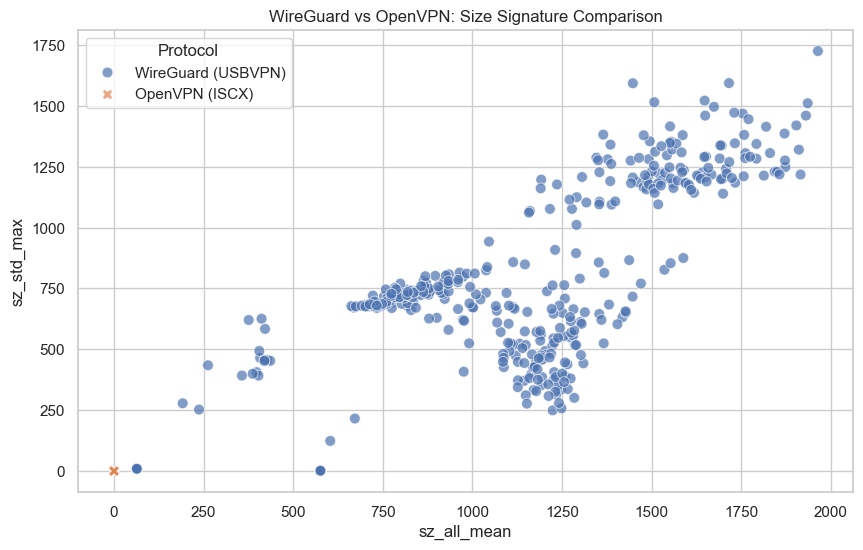

In [17]:
# Task 5: WireGuard vs. The World (Protocol Deep-Dive)
print("\n--- Task 5: WireGuard vs. The World (Protocol Deep-Dive) ---")
proto_features = ["sz_all_mean", "sz_std_max"]
available_proto = [f for f in proto_features if f in forensic_df.columns]

if len(available_proto) == 2 and "capture_id" in forensic_df.columns:
    # Identify WireGuard in USBVPN
    # We will try to find "wireguard" in the capture_id
    usbvpn_wg = forensic_df[(forensic_df["dataset"] == "usbvpn") &
                            (forensic_df["capture_id"].astype(str).str.lower().str.contains("wireguard|wg", na=False))]

    if len(usbvpn_wg) == 0:
        logger.warning("No explicit 'wireguard' captures found in USBVPN. Falling back to all VPN flows in USBVPN.")
        usbvpn_wg = forensic_df[(forensic_df["dataset"] == "usbvpn") & (forensic_df["label"] == 1)]

    # Identify OpenVPN in ISCX
    # We will try to find "openvpn" in the capture_id
    iscx_ovpn = forensic_df[(forensic_df["dataset"] == "iscx") &
                            (forensic_df["capture_id"].astype(str).str.lower().str.contains("openvpn|ovpn|vpn", na=False))]

    if len(iscx_ovpn) == 0:
        iscx_ovpn = forensic_df[(forensic_df["dataset"] == "iscx") & (forensic_df["label"] == 1)]

    # Sample 500 flows each
    wg_sample = usbvpn_wg.sample(min(500, len(usbvpn_wg)), random_state=42).copy() if len(usbvpn_wg) > 0 else pd.DataFrame()
    if not wg_sample.empty:
        wg_sample["Protocol"] = "WireGuard (USBVPN)"

    ovpn_sample = iscx_ovpn.sample(min(500, len(iscx_ovpn)), random_state=42).copy() if len(iscx_ovpn) > 0 else pd.DataFrame()
    if not ovpn_sample.empty:
        ovpn_sample["Protocol"] = "OpenVPN (ISCX)"

    if not wg_sample.empty and not ovpn_sample.empty:
        proto_df = pd.concat([wg_sample, ovpn_sample], ignore_index=True)

        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=proto_df, x="sz_all_mean", y="sz_std_max", hue="Protocol", style="Protocol", alpha=0.7, s=60)
        plt.title("WireGuard vs OpenVPN: Size Signature Comparison")
        plt.xlabel("sz_all_mean")
        plt.ylabel("sz_std_max")
        plt.show()
    else:
        print("Not enough flows to compare WireGuard and OpenVPN.")
else:
    print("Required features for Protocol Deep-Dive not found.")


In [18]:
print("\n" + "="*60)
print("STATISTICAL FINDINGS SUMMARY (For Discussion Section)")
print("="*60)
print("""
1. Dimensionality & Range Audit:
   - [Audit Results]: Checks for extreme outliers in USBVPN vs VNAT/ISCX which could break the StandardScaler during pooled fitting.

2. Visual Domain Overlap Analysis:
   - [KDE Overlap]: Reveals the degree of overlap in key feature spaces (e.g., sz_mean_max). A lack of overlap explains model failure across domains.

3. Class-Separability Check (Vanishing Signal):
   - [Correlation Shifts]: Demonstrates if the predictive power of anchor features (like sz_mean_max) shifts or 'vanishes' from 2016 (ISCX) to 2022 (USBVPN).

4. Feature Interaction Investigation:
   - [Correlation Matrices]: Evaluates the stability of the 'physics' of the VPN tunnel by comparing correlation matrices across eras.

5. Protocol Deep-Dive (WireGuard vs. The World):
   - [Size Signatures]: Identifies whether WireGuard possesses a distinct 'Size Signature' (sz_all_mean vs sz_std_max) compared to traditional OpenVPN, justifying domain shift.
""")


STATISTICAL FINDINGS SUMMARY (For Discussion Section)

1. Dimensionality & Range Audit:
   - [Audit Results]: Checks for extreme outliers in USBVPN vs VNAT/ISCX which could break the StandardScaler during pooled fitting.

2. Visual Domain Overlap Analysis:
   - [KDE Overlap]: Reveals the degree of overlap in key feature spaces (e.g., sz_mean_max). A lack of overlap explains model failure across domains.

3. Class-Separability Check (Vanishing Signal):
   - [Correlation Shifts]: Demonstrates if the predictive power of anchor features (like sz_mean_max) shifts or 'vanishes' from 2016 (ISCX) to 2022 (USBVPN).

4. Feature Interaction Investigation:
   - [Correlation Matrices]: Evaluates the stability of the 'physics' of the VPN tunnel by comparing correlation matrices across eras.

5. Protocol Deep-Dive (WireGuard vs. The World):
   - [Size Signatures]: Identifies whether WireGuard possesses a distinct 'Size Signature' (sz_all_mean vs sz_std_max) compared to traditional OpenVPN, justifyin